<a href="https://colab.research.google.com/github/fxrdhan/ISIC2018_UNet_vs_AttUNet_Segmentation_Riset/blob/main/Copy%20of%20ISIC2018_UNet_vs_AttUNet_Segmentation_Riset_submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Studi Komparatif U-Net dan Attention U-Net untuk Segmentasi Lesi Kulit pada ISIC 2018**
---

## List of contents
1. Introduction  
2. EDA (Exploratory Data Analysis)  
3. Dasar Teori
4. Pipeline   
5. Implementasi & Training  
6. Evaluasi & Perbandingan Model  
7. Kesimpulan dan Saran  
8. Referensi


## **1. Pendahuluan**

### **Latar Belakang**
Dermoskopi merupakan teknik pencitraan non-invasif yang meningkatkan visualisasi struktur lesi kulit dan membantu pembedaan kondisi jinak vs ganas, sehingga menjadi penting dalam konteks deteksi/analisis lesi kulit [1].  

Dalam pengolahan citra dermoskopi, segmentasi batas lesi merupakan tahap menentukan area target yang akan dianalisis lebih lanjut (mis. bentuk/luas/fitur), serta mengurangi pengaruh background dan artefak. Dataset ISIC 2018 Challenge – Task 1 secara khusus menargetkan prediksi batas segmentasi lesi pada citra dermoskopi [2], [3].

Arsitektur encoder–decoder seperti U-Net banyak digunakan sebagai baseline segmentasi biomedis karena menggabungkan informasi konteks dan detail spasial melalui *skip connection*, sehingga mendukung lokalisasi yang presisi [4].  
Pengembangan seperti Attention U-Net menambahkan *attention gate* pada jalur skip untuk menekan fitur yang tidak relevan dan menonjolkan area penting, dengan tujuan meningkatkan sensitivitas dan akurasi segmentasi pada struktur target [5].

### **Tujuan**
Membandingkan performa U-Net dan Attention U-Net pada dataset ISIC 2018 Task 1 menggunakan metrik:
- IoU (Jaccard Index)
- Dice Coefficient

### **Rumusan Masalah**
Apakah Attention U-Net memberikan peningkatan performa segmentasi dibanding U-Net standar pada ISIC 2018 Task 1 (berdasarkan IoU dan Dice) dengan pipeline eksperimen yang sama?

### **Batasan Masalah**
1. Tugas segmentasi biner (lesi vs background) pada ISIC 2018 Task 1 [2].
2. Evaluasi dilakukan secara lokal (offline) dengan membagi training set menjadi train/val/test (holdout) karena ground truth tersedia pada training set. Dengan demikian, “test” pada penelitian ini adalah data holdout dari training set, bukan official test set pada leaderboard ISIC.
3. Preprocessing dengan resize citra dan mask ke 512×512 dan normalisasi input.  
4. Model yang dibandingkan hanya U-Net dan Attention U-Net, dilatih dengan konfigurasi training yang sama (optimizer, lr, epoch, loss) [4], [5].
5. Metrik evaluasi dibatasi pada IoU dan Dice.


## **Setup & Konfigurasi**
Pada bagian ini:
- Import library
- Atur random seed (reproducible)
- Menentukan path dataset dan hyperparameter


### Import Libraries

In [ ]:
from pathlib import Path
import random, math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

def seed_everything(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = not deterministic

seed_everything(42, deterministic=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Konfigurasi Hyperparameter dan path dataset

In [ ]:
CFG = {
    "DATA_ROOT": Path("data/isic2018_raw"),
    "IMAGES_DIR": "ISIC2018_Task1-2_Training_Input",
    "MASKS_DIR": "ISIC2018_Task1_Training_GroundTruth",

    "IMG_SIZE": 512,
    "BATCH_SIZE": 8,
    "NUM_WORKERS": 4,

    "EPOCHS": 10,
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-5,

    "VAL_RATIO": 0.1,
    "TEST_RATIO": 0.1,

    "THRESHOLD": 0.5,
    "SAVE_DIR": Path("checkpoints"),
}

CFG["SAVE_DIR"].mkdir(parents=True, exist_ok=True)

images_path = CFG["DATA_ROOT"] / CFG["IMAGES_DIR"]
masks_path  = CFG["DATA_ROOT"] / CFG["MASKS_DIR"]

images_path, masks_path

(PosixPath('data/isic2018_raw/ISIC2018_Task1-2_Training_Input'),
 PosixPath('data/isic2018_raw/ISIC2018_Task1_Training_GroundTruth'))

## **Download & Extract ISIC 2018**

Pada tahap ini, dataset ISIC 2018 Task 1 diunduh dalam bentuk file `.zip` dari sumber resmi ISIC.
Setelah diunduh, file diekstrak ke folder `CFG["DATA_ROOT"]`.

Jika folder hasil ekstraksi sudah ada dan tidak kosong maka proses download/extract dilewati (*skip*).

In [ ]:
import zipfile
from pathlib import Path
from tqdm.auto import tqdm
import requests

URLS = {
  "train_input": "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1-2_Training_Input.zip",
  "train_gt":    "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task1_Training_GroundTruth.zip",
}

RAW_DIR = Path(CFG["DATA_ROOT"])
RAW_DIR.mkdir(parents=True, exist_ok=True)

def download_with_progress(url, dest_path):
    """Download file dengan progress bar"""
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(dest_path, 'wb') as f, tqdm(
        desc=dest_path.name,
        total=total_size,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

for name, url in URLS.items():
    zip_filename = Path(url).name
    zip_path = RAW_DIR / zip_filename
    out_dir = RAW_DIR / zip_path.stem

    # Cek apakah sudah di-extract
    if out_dir.exists() and any(out_dir.iterdir()):
        print(f"[SKIP] {out_dir}")
        continue

    print(f"\n[DOWNLOADING] {name}")
    if not zip_path.exists():
        download_with_progress(url, zip_path)
    else:
        print(f"  File already exists: {zip_path.name}")

    print(f"[EXTRACTING] {zip_path.name}")
    with zipfile.ZipFile(zip_path) as z:
        members = z.namelist()
        for member in tqdm(members, desc="Extracting"):
            z.extract(member, RAW_DIR)

    print(f"[READY] {out_dir}\n")

[SKIP] data/isic2018_raw/ISIC2018_Task1-2_Training_Input
[SKIP] data/isic2018_raw/ISIC2018_Task1_Training_GroundTruth


## **2. EDA**

EDA yang dilakukan:
- Cek jumlah data dan kesesuaian pasangan image–mask
- Visualisasi contoh image + overlay mask
- Distribusi ukuran gambar (H×W)
- Distribusi luas lesi (persentase area mask)


In [ ]:
from pathlib import Path

# pastikan path folder benar
images_path = CFG["DATA_ROOT"] / CFG["IMAGES_DIR"]
masks_path  = CFG["DATA_ROOT"] / CFG["MASKS_DIR"]

print("images_path:", images_path, "| exists:", images_path.exists())
print("masks_path :", masks_path,  "| exists:", masks_path.exists())

def list_image_mask_pairs(images_dir, masks_dir,
                          img_exts=(".jpg", ".jpeg", ".png"),
                          mask_exts=(".png", ".jpg", ".jpeg")):
    images_dir = Path(images_dir)
    masks_dir  = Path(masks_dir)

    # collect images (case-insensitive)
    img_files = [p for p in images_dir.rglob("*") if p.is_file() and p.suffix.lower() in img_exts]
    img_files = sorted(img_files)

    # normalize mask stem: handle *_segmentation
    def norm_mask_stem(stem: str) -> str:
        for suf in ("_segmentation", "_mask"):
            if stem.endswith(suf):
                return stem[: -len(suf)]
        return stem

    # map masks by normalized stem
    mask_map = {}
    for p in masks_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in mask_exts:
            key = norm_mask_stem(p.stem)
            # keep first occurrence
            mask_map.setdefault(key, p)

    pairs = []
    missing = 0
    for img_p in img_files:
        mask_p = mask_map.get(img_p.stem)
        if mask_p is None:
            missing += 1
        else:
            pairs.append((img_p, mask_p))

    return pairs, missing, img_files, list(mask_map.values())

pairs, missing, img_files, mask_files = list_image_mask_pairs(images_path, masks_path)

print("n_images:", len(img_files))
print("n_masks :", len(mask_files))
print("pairs   :", len(pairs), "| missing_masks:", missing)

if img_files:
    print("example image:", img_files[0].name)
if mask_files:
    print("example mask :", mask_files[0].name)

print("sample pairs:")
for i, (ip, mp) in enumerate(pairs[:3]):
    print(i, ip.name, "->", mp.name)

images_path: data/isic2018_raw/ISIC2018_Task1-2_Training_Input | exists: True
masks_path : data/isic2018_raw/ISIC2018_Task1_Training_GroundTruth | exists: True
n_images: 2594
n_masks : 2594
pairs   : 2594 | missing_masks: 0
example image: ISIC_0000000.jpg
example mask : ISIC_0015603_segmentation.png
sample pairs:
0 ISIC_0000000.jpg -> ISIC_0000000_segmentation.png
1 ISIC_0000001.jpg -> ISIC_0000001_segmentation.png
2 ISIC_0000003.jpg -> ISIC_0000003_segmentation.png


### Hasil Validasi Data

Hasil pengecekan awal menunjukkan:
- Jumlah citra dan mask seimbang.
- Tidak ditemukan mask yang hilang.


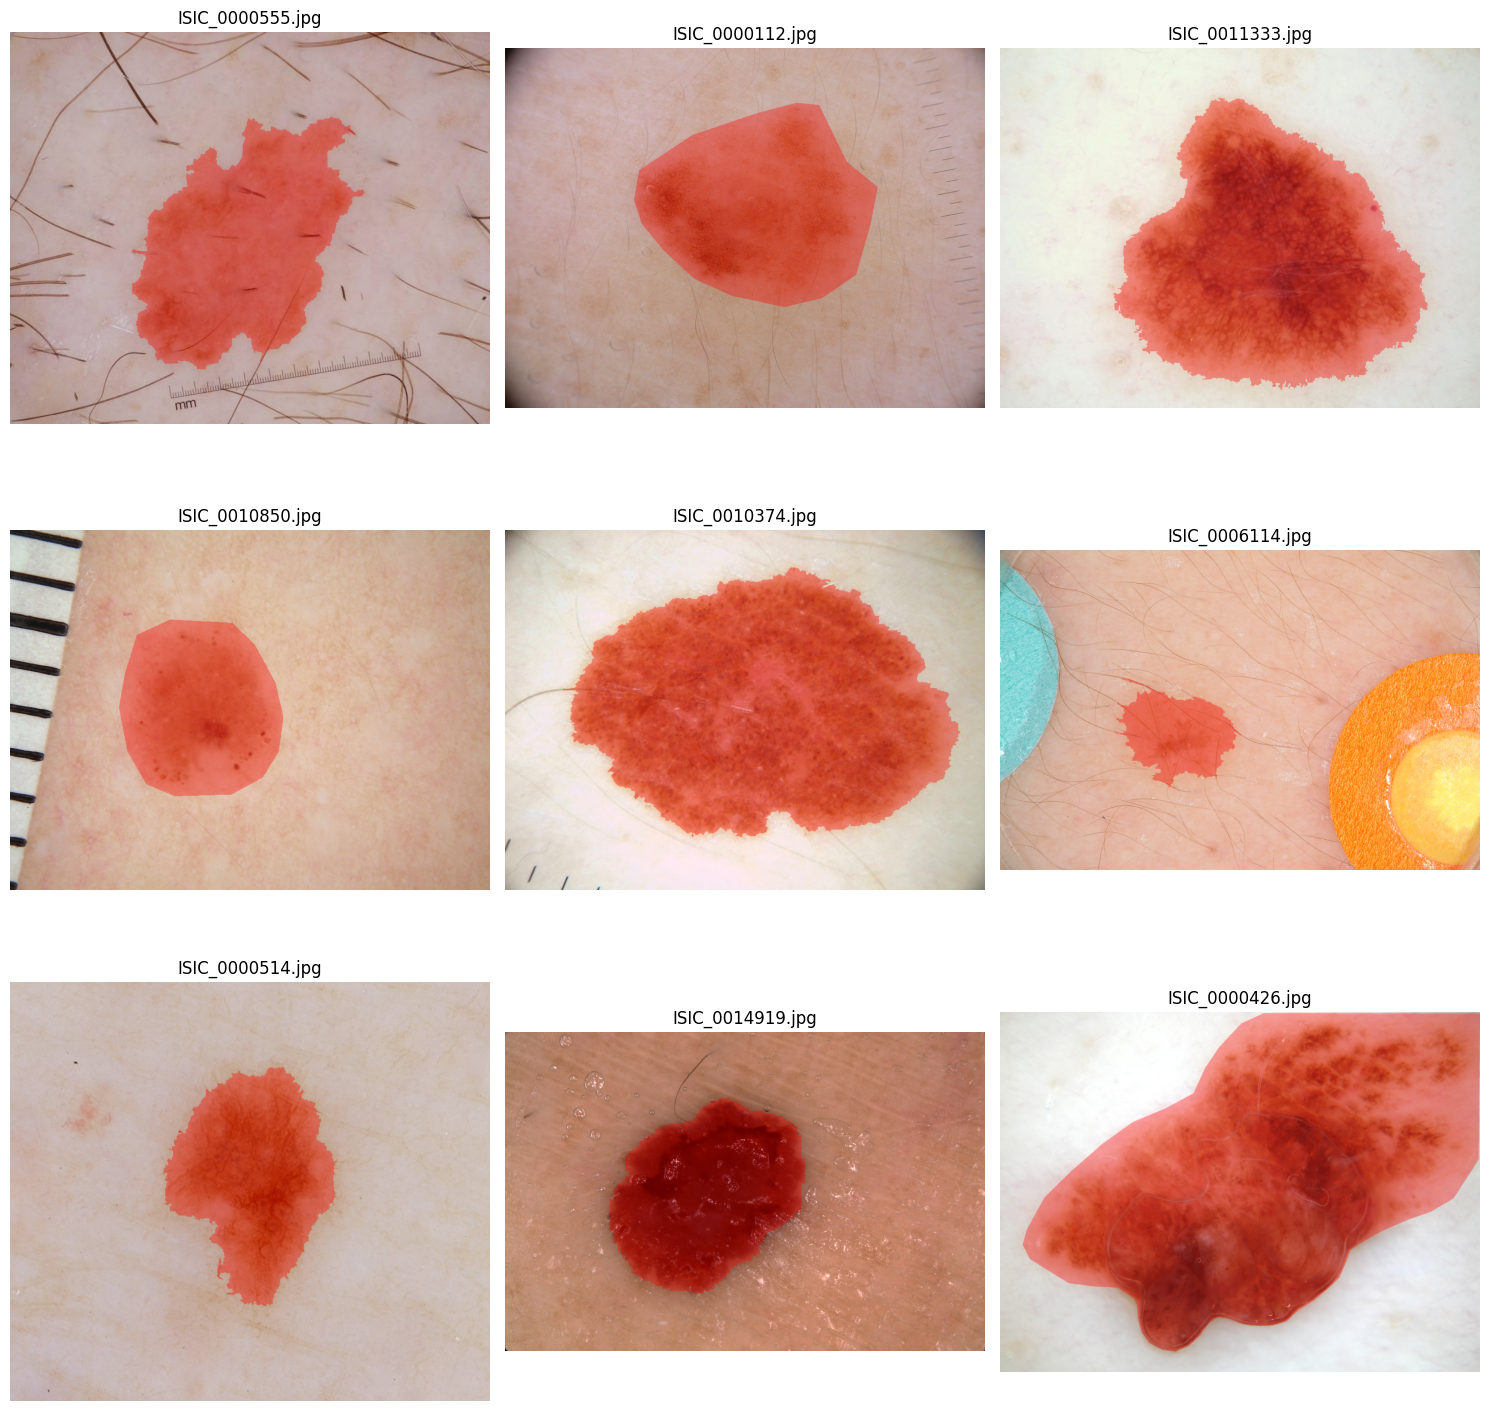

In [ ]:
def read_rgb(p):  return np.array(Image.open(p).convert("RGB"))
def read_mask(p): return (np.array(Image.open(p).convert("L")) > 0).astype(np.uint8)

def show_samples(pairs, n=9, seed=42, alpha=0.35):
    rnd = random.Random(seed)
    sample = rnd.sample(pairs, k=min(n, len(pairs)))

    cols = 3
    rows = math.ceil(len(sample) / cols)
    plt.figure(figsize=(cols*5, rows*5))

    for i, (img_p, mask_p) in enumerate(sample, 1):
        img = read_rgb(img_p)
        m = read_mask(mask_p).astype(bool)

        out = img.copy()
        out[m] = ((1 - alpha) * out[m] + alpha * np.array([255, 0, 0])).astype(np.uint8)

        plt.subplot(rows, cols, i)
        plt.imshow(out)
        plt.title(img_p.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

if pairs:
    show_samples(pairs, n=9, seed=42)

### Observasi Awal

Dari beberapa sampel memperlihatkan bahwa:
- Mask biner mengikuti batas lesi dengan cukup baik, namun beberapa kasus memiliki batas yang tidak tegas/blur.
- Background pada citra dermoskopi memiliki variasi (warna kulit, tekstur, artefak) yang berpotensi menambah noise.

Reading sizes:   0%|          | 0/2594 [00:00<?, ?it/s]

,H,W
count,2594.000000,2594.000000
mean,2166.791442,3188.266384
std,1241.344101,1923.091567
min,540.000000,576.000000
25%,768.000000,1024.000000
50%,2000.000000,3008.000000
75%,2848.000000,4288.000000
max,4499.000000,6748.000000


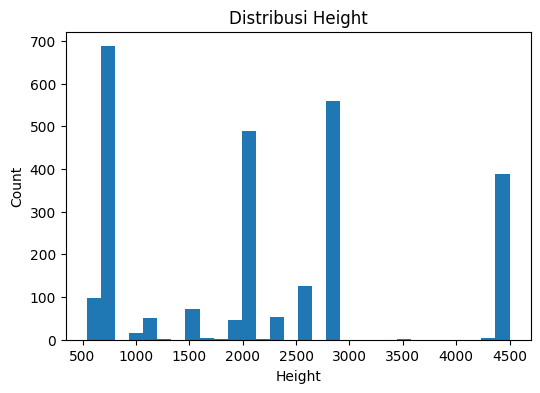

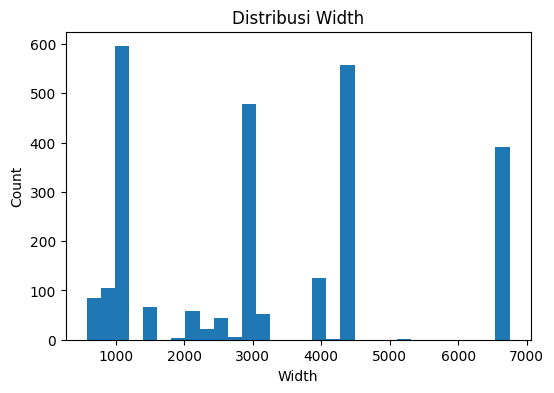

In [ ]:
# Distribusi ukuran gambar
def compute_image_sizes(pairs):
    sizes = []
    for img_p, _ in tqdm(pairs, desc="Reading sizes"):
        with Image.open(img_p) as im:
            w, h = im.size
        sizes.append((h, w))
    return pd.DataFrame(sizes, columns=["H", "W"])

if len(pairs) > 0:
    df_sizes = compute_image_sizes(pairs)
    display(df_sizes.describe())

    plt.figure(figsize=(6,4))
    plt.hist(df_sizes["H"], bins=30)
    plt.title("Distribusi Height")
    plt.xlabel("Height")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.hist(df_sizes["W"], bins=30)
    plt.title("Distribusi Width")
    plt.xlabel("Width")
    plt.ylabel("Count")
    plt.show()

### Implikasi Distribusi Ukuran Gambar

Karena ukuran citra bervariasi, dilakukan resize ke **512×512** untuk menyamakan dimensi input model (kebutuhan batching) dan menjaga biaya komputasi tetap wajar.

Dengan catatan adanya konsekuensi dimana resize dapat mengurangi detail batas lesi pada sebagian kasus.


Reading masks:   0%|          | 0/2594 [00:00<?, ?it/s]

,lesion_area_ratio
count,2594.000000
mean,0.214021
std,0.208366
min,0.002977
25%,0.051731
50%,0.138084
75%,0.318733
max,0.986650


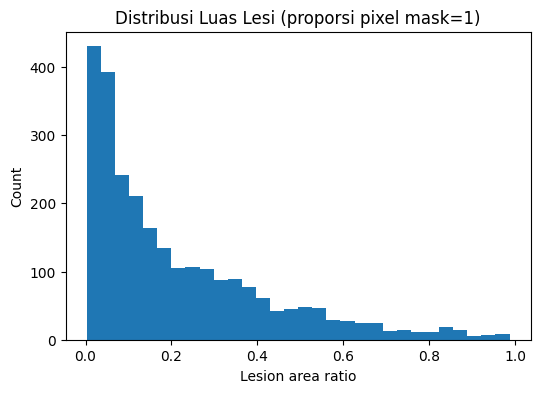

In [ ]:
# Distribusi luas lesi (persentase area mask)
def compute_lesion_area_ratio(pairs):
    ratios = []
    for _, mask_p in tqdm(pairs, desc="Reading masks"):
        m = (np.array(Image.open(mask_p).convert("L")) > 0).astype(np.uint8)
        m = (m > 0).astype(np.uint8)
        ratios.append(float(m.mean()))  # proporsi pixel lesi
    return pd.DataFrame({"lesion_area_ratio": ratios})

if len(pairs) > 0:
    df_area = compute_lesion_area_ratio(pairs)
    display(df_area.describe())

    plt.figure(figsize=(6,4))
    plt.hist(df_area["lesion_area_ratio"], bins=30)
    plt.title("Distribusi Luas Lesi (proporsi pixel mask=1)")
    plt.xlabel("Lesion area ratio")
    plt.ylabel("Count")
    plt.show()

### Implikasi Distribusi Luas Lesi (Class Imbalance)

Distribusi `lesion_area_ratio` menunjukkan variasi ukuran lesi dimana banyak contoh dengan lesi relatif kecil dibanding total area gambar, hal ini berpotensi menimbulkan ketidakseimbangan kelas (foreground lebih sedikit daripada background).

Loss berbasis overlap seperti **Dice Loss** membantu mengurangi bias terhadap background.


## **3. Dasar Teori**

### **U-Net**

U-Net (U-shaped Network) adalah arsitektur encoder–decoder dengan skip connections:
- Encoder mengekstrak fitur semantik (downsampling).
- Decoder mengembalikan resolusi spasial (upsampling).
- Skip connection menggabungkan fitur resolusi tinggi dari encoder agar detail batas objek terjaga.

![alt text](https://media.geeksforgeeks.org/wp-content/uploads/20220614121231/Group14.jpg)

Arsitektur U-Net seperti namanya berbentuk huruf "U", terdiri dari dua bagian besar:

1. Contracting path (Encoder / downsampling) di sisi kiri
2. Expanding path (Decoder / upsampling) di sisi kanan
   yang dihubungkan oleh skip connection (panah hitam panjang "copy and crop").

#### 1) Encoder (kiri) untuk menangkap konteks

* Setiap level encoder melakukan:

  * Conv 3×3 + ReLU (panah ungu) sebanyak 2 kali untuk mengekstraksi fitur.
  * Max Pool 2×2 (panah merah) untuk mengecilkan resolusi (downsampling).
* Saat resolusi turun, jumlah channel fitur naik (mis. 64 - 128 - 256 - 512 - 1024).
  Tujuannya: semakin dalam, fitur makin "abstrak" dan kaya konteks.

#### 2) Bottleneck (titik terdalam)

* Bagian paling bawah (sekitar channel 1024) adalah fitur paling "padat":

  * resolusi paling kecil,
  * informasi konteks global paling kuat.

#### 3) Decoder (kanan) untuk mengembalikan detail lokasi

* Setiap level decoder melakukan:

  * Up-conv 2×2 (panah hijau) untuk memperbesar resolusi (upsampling).
  * Concatenate dengan fitur dari encoder melalui skip connection (panah hitam "copy and crop").
  * Lalu Conv 3×3 + ReLU lagi untuk memadukan fitur konteks + detail.
* Saat resolusi naik, jumlah channel biasanya turun (mis. 512 - 256 - 128 - 64), karena model mulai membangun kembali peta segmentasi pada resolusi tinggi.

#### 4) Skip connection ("copy and crop")

* Skip connection mengirimkan fitur dari encoder (yang masih kaya detail spasial/boundary) ke decoder.
* Ini penting karena:

  * Encoder cenderung kehilangan detail batas akibat pooling,
  * Decoder butuh detail tersebut untuk segmentasi yang presisi.

#### 5) Output layer: Conv 1×1

* Di ujung kanan ada Conv 1×1 (panah biru) yang memetakan fitur menjadi jumlah kelas output.
* Pada diagram tertulis output "2" (dua kelas: objek vs background).
  Pada implementasi nanti akan dihasilkan 1 channel logit (lesi vs background), lalu diubah jadi probabilitas dengan sigmoid dan dibinarisasi dengan threshold.



### **Attention U-Net**
Attention U-Net menambahkan Attention Gate (AG) di jalur skip connection:
- AG menerima fitur dari encoder (x) dan sinyal gating dari decoder (g).
- AG menghasilkan koefisien attention untuk menekankan area relevan (lesi) dan menekan noise/background.

![gambar](https://drive.google.com/uc?export=view&id=1VjOufaX0bpvTHScC7_uOPe9icN5dC-2G)

Attention U-Net menambahkan **Attention Gate** pada **skip connection** untuk menyaring fitur dari encoder, sehingga decoder menerima fitur yang lebih fokus pada area lesi.

### **3.3 Loss Function (BCE + Dice)**

Eksperimen menggunakan kombinasi:
- Binary Cross Entropy with Logits (BCEWithLogits) yang mendorong prediksi pixel-wise benar.
- Dice Loss yang fokus pada kemiripan wilayah tumpang tindih antara hasil prediksi dan label sebenarnya.

Secara singkat:
- Dice Coefficient mengukur tingkat tumpang tindih:
  $$
  Dice = \frac{2|P \cap G|}{|P| + |G|}
  $$
- IoU menghitung perbandingan tumpang tindih terhadap gabungan wilayah:
  $$
  IoU = \frac{|P \cap G|}{|P \cup G|}
  $$

Penggabungan BCE dan Dice sering diterapkan pada segmentasi citra medis karena:
- BCE memberikan stabilitas pada tahap awal pelatihan,
- Dice lebih sensitif terhadap ketimpangan kelas (misalnya lesi berukuran kecil dibandingkan latar belakang yang luas).


## **4. Pipeline**

![gambar](https://drive.google.com/uc?export=view&id=1xJfgEcJeJWm4igAr18A791DO0jAQ-7E1)

1. **Load data** (image, mask)  
2. **Preprocessing**: resize, normalisasi [0,1]  
3. **Split data**: train/val/test  
4. **Training**:  
   - Loss = BCEWithLogits + Dice Loss  
   - Optimizer = Adam  
5. **Evaluasi** pada test set: IoU & Dice  
6. **Analisis kualitatif**: prediksi mask dari kedua model


## **5. Implementasi**
Bagian ini berisi:
- Dataset class & DataLoader
- Implementasi U-Net
- Implementasi Attention U-Net
- Loss & metric
- Training loop & evaluasi


### Dataset & DataLoader

In [ ]:
def read_rgb(p: Path) -> Image.Image:
    return Image.open(p).convert("RGB")

def read_mask(p: Path) -> Image.Image:
    return Image.open(p).convert("L")

def resize_pil(im, size: int, is_mask: bool = False):
    if isinstance(im, np.ndarray):
        im = Image.fromarray(im)

    # pilih resampling yang kompatibel
    if hasattr(Image, "Resampling"):
        r = Image.Resampling.NEAREST if is_mask else Image.Resampling.BILINEAR
    else:
        r = Image.NEAREST if is_mask else Image.BILINEAR

    # pakai positional arg
    return im.resize((int(size), int(size)), r)

class ISICSegDataset(Dataset):
    def __init__(self, pairs, img_size=256, augment=False):
        self.pairs = pairs
        self.img_size = int(img_size)
        self.augment = bool(augment)

    def __len__(self):
        return len(self.pairs)

    def _simple_augment(self, img_hwc, mask_hw):
        # flip sinkron (augment sederhana)
        if random.random() < 0.5:
            img_hwc = np.flip(img_hwc, axis=1)
            mask_hw = np.flip(mask_hw, axis=1)
        if random.random() < 0.2:
            img_hwc = np.flip(img_hwc, axis=0)
            mask_hw = np.flip(mask_hw, axis=0)

        # pastikan contiguous
        return img_hwc.copy(), mask_hw.copy()

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        # baca sebagai PIL
        img = read_rgb(img_path)
        mask = read_mask(mask_path)

        # resize
        img = resize_pil(img, self.img_size, is_mask=False)
        mask = resize_pil(mask, self.img_size, is_mask=True)

        # ke numpy float
        img = np.array(img).astype(np.float32) / 255.0 # H,W,3
        mask = (np.array(mask) > 0).astype(np.float32) # H,W

        # augment jika perlu
        if self.augment:
            img, mask = self._simple_augment(img, mask)

        # ke tensor
        img_t = torch.from_numpy(img).permute(2, 0, 1) # 3,H,W
        mask_t = torch.from_numpy(mask).unsqueeze(0) # 1,H,W
        return img_t, mask_t

def make_splits(pairs, val_ratio=0.1, test_ratio=0.1, seed=42):
    idx = np.arange(len(pairs))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n = len(idx)
    n_test = int(n * float(test_ratio))
    n_val  = int(n * float(val_ratio))

    test_idx  = idx[:n_test]
    val_idx   = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    pick = lambda ii: [pairs[int(i)] for i in ii]
    return pick(train_idx), pick(val_idx), pick(test_idx)

# buat splits
if len(pairs) > 0:
    train_pairs, val_pairs, test_pairs = make_splits(
        pairs, val_ratio=CFG["VAL_RATIO"], test_ratio=CFG["TEST_RATIO"], seed=42
    )
    print("train/val/test:", len(train_pairs), len(val_pairs), len(test_pairs))
else:
    print("pairs masih kosong. cek folder path / pairing masks.")

train/val/test: 2076 259 259


### Note

Split dilakukan secara acak menggunakan seed tetap untuk menjaga reprodusibilitas.

Komposisi:
- Train: 2076 sampel
- Validation: 259 sampel
- Test (holdout): 259 sampel

Validation digunakan untuk memilih checkpoint terbaik berdasarkan val IoU.
Test (holdout) digunakan untuk evaluasi akhir perbandingan model.


In [ ]:
if len(pairs) > 0:
    train_ds = ISICSegDataset(train_pairs, img_size=CFG["IMG_SIZE"], augment=True)
    val_ds   = ISICSegDataset(val_pairs,   img_size=CFG["IMG_SIZE"], augment=False)
    test_ds  = ISICSegDataset(test_pairs,  img_size=CFG["IMG_SIZE"], augment=False)

    train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], shuffle=True,
                              num_workers=CFG["NUM_WORKERS"], pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CFG["BATCH_SIZE"], shuffle=False,
                              num_workers=CFG["NUM_WORKERS"], pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=CFG["BATCH_SIZE"], shuffle=False,
                              num_workers=CFG["NUM_WORKERS"], pin_memory=True)


### Building blocks

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )
    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        self.bilinear = bilinear
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX//2, diffX-diffX//2, diffY//2, diffY-diffY//2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x):
        return self.conv(x)


### U-Net

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=64, bilinear=True):
        super().__init__()
        self.inc = DoubleConv(in_ch, base_ch)
        self.down1 = Down(base_ch, base_ch*2)
        self.down2 = Down(base_ch*2, base_ch*4)
        self.down3 = Down(base_ch*4, base_ch*8)
        factor = 2 if bilinear else 1
        self.down4 = Down(base_ch*8, base_ch*16//factor)

        self.up1 = Up(base_ch*16, base_ch*8//factor, bilinear)
        self.up2 = Up(base_ch*8,  base_ch*4//factor, bilinear)
        self.up3 = Up(base_ch*4,  base_ch*2//factor, bilinear)
        self.up4 = Up(base_ch*2,  base_ch, bilinear)
        self.outc = OutConv(base_ch, out_ch)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)
        return self.outc(x)


### Attention Gate & Attention U-Net

In [ ]:
class AttentionGate(nn.Module):
    """Attention gate (AG): x = encoder feature, g = gating (decoder feature)."""
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=64, bilinear=True):
        super().__init__()
        self.inc = DoubleConv(in_ch, base_ch)
        self.down1 = Down(base_ch, base_ch*2)
        self.down2 = Down(base_ch*2, base_ch*4)
        self.down3 = Down(base_ch*4, base_ch*8)
        factor = 2 if bilinear else 1
        self.down4 = Down(base_ch*8, base_ch*16//factor)

        self.up1 = Up(base_ch*16, base_ch*8//factor, bilinear)
        self.up2 = Up(base_ch*8,  base_ch*4//factor, bilinear)
        self.up3 = Up(base_ch*4,  base_ch*2//factor, bilinear)
        self.up4 = Up(base_ch*2,  base_ch, bilinear)

        self.ag1 = AttentionGate(F_g=base_ch*16//factor, F_l=base_ch*8, F_int=base_ch*4)
        self.ag2 = AttentionGate(F_g=base_ch*8//factor,  F_l=base_ch*4, F_int=base_ch*2)
        self.ag3 = AttentionGate(F_g=base_ch*4//factor,  F_l=base_ch*2, F_int=base_ch)
        self.ag4 = AttentionGate(F_g=base_ch*2//factor,  F_l=base_ch,   F_int=max(1, base_ch//2))

        self.outc = OutConv(base_ch, out_ch)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        # gating signals from decoder features (upsampled as needed)
        g4 = F.interpolate(x5, size=x4.shape[-2:], mode="bilinear", align_corners=True)
        x4_att = self.ag1(x4, g4)
        d1 = self.up1(x5, x4_att)

        g3 = F.interpolate(d1, size=x3.shape[-2:], mode="bilinear", align_corners=True)
        x3_att = self.ag2(x3, g3)
        d2 = self.up2(d1, x3_att)

        g2 = F.interpolate(d2, size=x2.shape[-2:], mode="bilinear", align_corners=True)
        x2_att = self.ag3(x2, g2)
        d3 = self.up3(d2, x2_att)

        g1 = F.interpolate(d3, size=x1.shape[-2:], mode="bilinear", align_corners=True)
        x1_att = self.ag4(x1, g1)
        d4 = self.up4(d3, x1_att)

        return self.outc(d4)


### Loss & Metrics

In [ ]:
def dice_coef(pred, target, eps=1e-7):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean()

def iou_score(pred, target, eps=1e-7):
    pred = pred.contiguous()
    target = target.contiguous()
    intersection = (pred * target).sum(dim=(2,3))
    total = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    union = total - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        return 1.0 - dice_coef(probs, targets, eps=self.eps)

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(logits, targets, alpha=0.5):
    return alpha * bce_loss(logits, targets) + (1 - alpha) * dice_loss(logits, targets)

### Training & Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    losses, dices, ious = [], [], []

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(imgs)
        loss = combined_loss(logits, masks)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        losses.append(loss.item())
        dices.append(dice_coef(preds, masks).item())
        ious.append(iou_score(preds, masks).item())

    return {
        "loss": float(np.mean(losses)) if losses else None,
        "dice": float(np.mean(dices)) if dices else None,
        "iou":  float(np.mean(ious))  if ious  else None,
    }

def train_one_epoch(model, loader, optimizer, scaler=None, threshold=0.5):
    model.train()
    losses, dices, ious = [], [], []

    use_amp = (scaler is not None) and (device.type == "cuda")

    for imgs, masks in tqdm(loader, desc="train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.amp.autocast("cuda", enabled=True):
                logits = model(imgs)
                loss = combined_loss(logits, masks)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss = combined_loss(logits, masks)
            loss.backward()
            optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).float()
            losses.append(loss.item())
            dices.append(dice_coef(preds, masks).item())
            ious.append(iou_score(preds, masks).item())

    return {
        "loss": float(np.mean(losses)) if losses else None,
        "dice": float(np.mean(dices)) if dices else None,
        "iou":  float(np.mean(ious))  if ious  else None,
    }

def fit(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=1e-5, model_name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None

    history = []
    best_val_iou = -1.0
    ckpt_path = CFG["SAVE_DIR"] / f"{model_name}_best.pt"

    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, scaler=scaler, threshold=CFG["THRESHOLD"])
        va = evaluate(model, val_loader, threshold=CFG["THRESHOLD"])

        row = {
            "epoch": epoch,
            **{f"train_{k}": v for k, v in tr.items()},
            **{f"val_{k}": v for k, v in va.items()},
        }
        history.append(row)

        print(
            f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
            f"train loss {tr['loss']:.4f} dice {tr['dice']:.4f} iou {tr['iou']:.4f} | "
            f"val loss {va['loss']:.4f} dice {va['dice']:.4f} iou {va['iou']:.4f}"
        )

        if va["iou"] is not None and va["iou"] > best_val_iou:
            best_val_iou = va["iou"]
            torch.save(model.state_dict(), ckpt_path)

    return model, pd.DataFrame(history)

def plot_history(df_hist, title_prefix=""):
    if df_hist is None or len(df_hist) == 0:
        return

    plt.figure(figsize=(6, 4))
    plt.plot(df_hist["epoch"], df_hist["train_loss"], label="train_loss")
    plt.plot(df_hist["epoch"], df_hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(df_hist["epoch"], df_hist["train_iou"], label="train_iou")
    plt.plot(df_hist["epoch"], df_hist["val_iou"], label="val_iou")
    plt.title(f"{title_prefix} IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(df_hist["epoch"], df_hist["train_dice"], label="train_dice")
    plt.plot(df_hist["epoch"], df_hist["val_dice"], label="val_dice")
    plt.title(f"{title_prefix} Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.show()


## **Training: U-Net vs Attention U-Net**

Langkah yang digunakan:
1. Train model pada train set.
2. Evaluasi pada validation set setiap epoch.
3. Simpan checkpoint terbaik berdasarkan **val IoU**.
4. Setelah training selesai, load checkpoint terbaik dan evaluasi pada **test holdout**.

Validasi IoU merepresentasikan overlap secara ketat (penalti lebih besar pada false positive/false negative dibanding Dice).


In [ ]:
def run_experiment(model_factory, model_name):
    if len(pairs) == 0:
        raise RuntimeError(
            "Dataset belum tersedia. Pastikan CFG['DATA_ROOT'] benar dan folder images/masks ada."
        )

    model = model_factory()
    model, hist = fit(
        model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=CFG["EPOCHS"],
        lr=CFG["LR"],
        weight_decay=CFG["WEIGHT_DECAY"],
        model_name=model_name,
    )

    plot_history(hist, title_prefix=model_name)

    # load best checkpoint
    ckpt_path = CFG["SAVE_DIR"] / f"{model_name}_best.pt"
    if ckpt_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

    test_metrics = evaluate(model, test_loader, threshold=CFG["THRESHOLD"])
    return model, hist, test_metrics

UNetFactory = lambda: UNet(in_ch=3, out_ch=1, base_ch=64, bilinear=True)
AttUNetFactory = lambda: AttUNet(in_ch=3, out_ch=1, base_ch=64, bilinear=True)


train:   0%|          | 0/260 [00:00<?, ?it/s]

[unet] Epoch 01/10 | train loss 0.4467 dice 0.6178 iou 0.5081 | val loss 0.3411 dice 0.7028 iou 0.6022


train:   0%|          | 0/260 [00:00<?, ?it/s]

[unet] Epoch 02/10 | train loss 0.3830 dice 0.6593 iou 0.5511 | val loss 0.3522 dice 0.7050 iou 0.5995


train:   0%|          | 0/260 [00:00<?, ?it/s]

...

[unet] Epoch 08/10 | train loss 0.3137 dice 0.7261 iou 0.6218 | val loss 0.2996 dice 0.7465 iou 0.6512


train:   0%|          | 0/260 [00:00<?, ?it/s]

[unet] Epoch 09/10 | train loss 0.3117 dice 0.7301 iou 0.6272 | val loss 0.3270 dice 0.7083 iou 0.6084


train:   0%|          | 0/260 [00:00<?, ?it/s]

[unet] Epoch 10/10 | train loss 0.3024 dice 0.7398 iou 0.6366 | val loss 0.2862 dice 0.7689 iou 0.6748


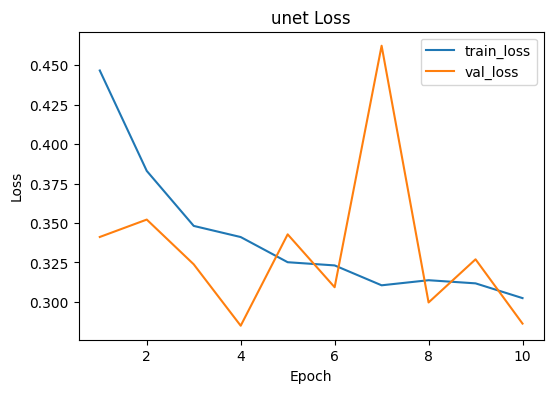

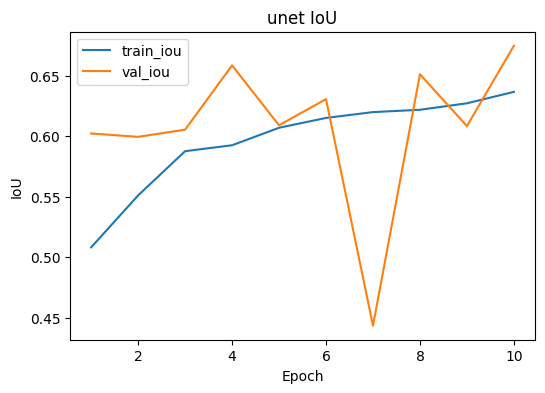

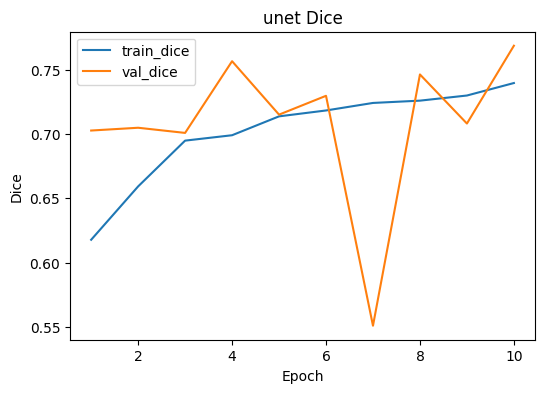

train:   0%|          | 0/260 [00:00<?, ?it/s]

[att_unet] Epoch 01/10 | train loss 0.4520 dice 0.6057 iou 0.4969 | val loss 0.3829 dice 0.6803 iou 0.5865


train:   0%|          | 0/260 [00:00<?, ?it/s]

[att_unet] Epoch 02/10 | train loss 0.3899 dice 0.6539 iou 0.5480 | val loss 0.4756 dice 0.5318 iou 0.4300


train:   0%|          | 0/260 [00:00<?, ?it/s]

...

[att_unet] Epoch 08/10 | train loss 0.3106 dice 0.7251 iou 0.6198 | val loss 0.3778 dice 0.7181 iou 0.6271


train:   0%|          | 0/260 [01:40<?, ?it/s]

[att_unet] Epoch 09/10 | train loss 0.3106 dice 0.7293 iou 0.6248 | val loss 0.3269 dice 0.7084 iou 0.6135


train:   0%|          | 0/260 [00:00<?, ?it/s]

[att_unet] Epoch 10/10 | train loss 0.3106 dice 0.7309 iou 0.6264 | val loss 0.3242 dice 0.7042 iou 0.6038


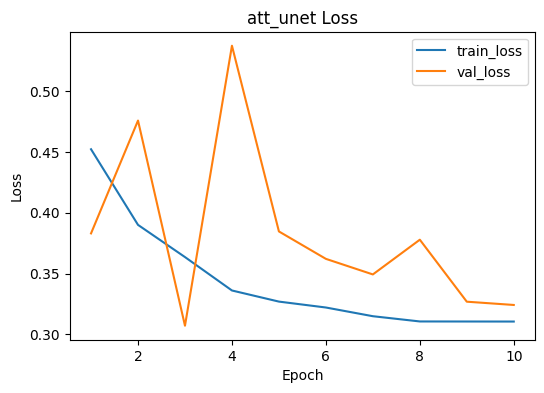

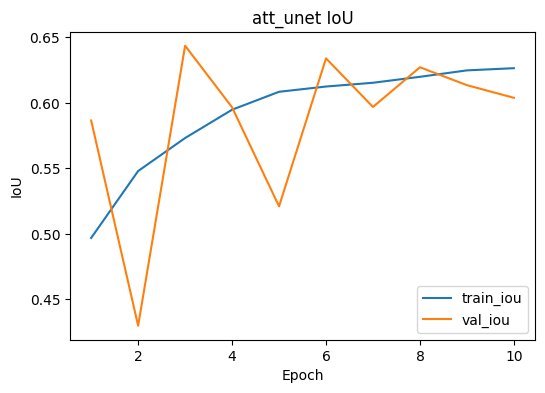

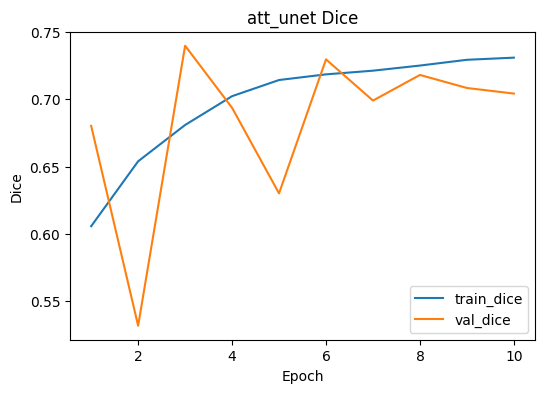

In [ ]:
# --- U-Net ---
unet_model, unet_hist, unet_test = run_experiment(UNetFactory, "unet")

# --- Attention U-Net ---
att_model, att_hist, att_test = run_experiment(AttUNetFactory, "att_unet")

,model,loss,dice,iou
0,U-Net,0.297088,0.760903,0.663949
1,Attention U-Net,0.331331,0.710196,0.603648


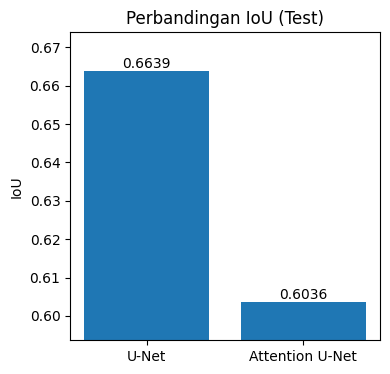

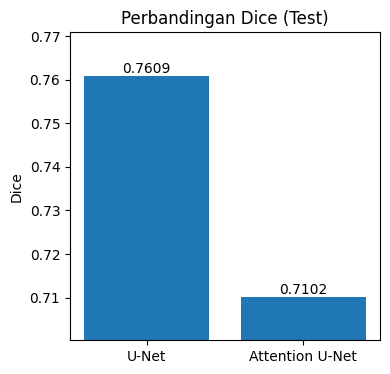

In [ ]:
results = pd.DataFrame([
    {"model": "U-Net", **unet_test},
    {"model": "Attention U-Net", **att_test},
])
display(results)

plt.figure(figsize=(4,4))
plt.bar(results["model"], results["iou"])
plt.title("Perbandingan IoU (Test)")
plt.ylabel("IoU")

ymin = results["iou"].min() - 0.01
ymax = results["iou"].max() + 0.01
plt.ylim(ymin, ymax)

for i, v in enumerate(results["iou"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.show()

plt.figure(figsize=(4,4))
plt.bar(results["model"], results["dice"])
plt.title("Perbandingan Dice (Test)")
plt.ylabel("Dice")

ymin = results["dice"].min() - 0.01
ymax = results["dice"].max() + 0.01
plt.ylim(ymin, ymax)

for i, v in enumerate(results["dice"]):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.show()

## Hasil

- **U-Net**
  - Loss: **0.2971**
  - Dice: **0.7609**
  - IoU : **0.6639**

- **Attention U-Net**
  - Loss: **0.3313**
  - Dice: **0.7102**
  - IoU : **0.6036**

### Perbedaan Performa
- ΔIoU  = 0.6036 − 0.6639 = **−0.0603**
- ΔDice = 0.7102 − 0.7609 = **−0.0507**

### Interpretasi Singkat
Pada setup eksperimen ini, **U-Net standar menunjukkan performa yang lebih baik** dibanding Attention U-Net pada kedua metrik utama (IoU dan Dice).  
Attention U-Net tidak memberikan peningkatan performa secara kuantitatif pada test holdout, dan justru mengalami penurunan skor IoU dan Dice. Hal ini mengindikasikan bahwa penambahan attention gate belum memberikan keuntungan pada konfigurasi training dan augmentasi yang digunakan.


## **6. Evaluasi Kualitatif**

Bagian ini menampilkan beberapa contoh:
- input image
- ground truth mask
- prediksi U-Net
- prediksi Attention U-Net


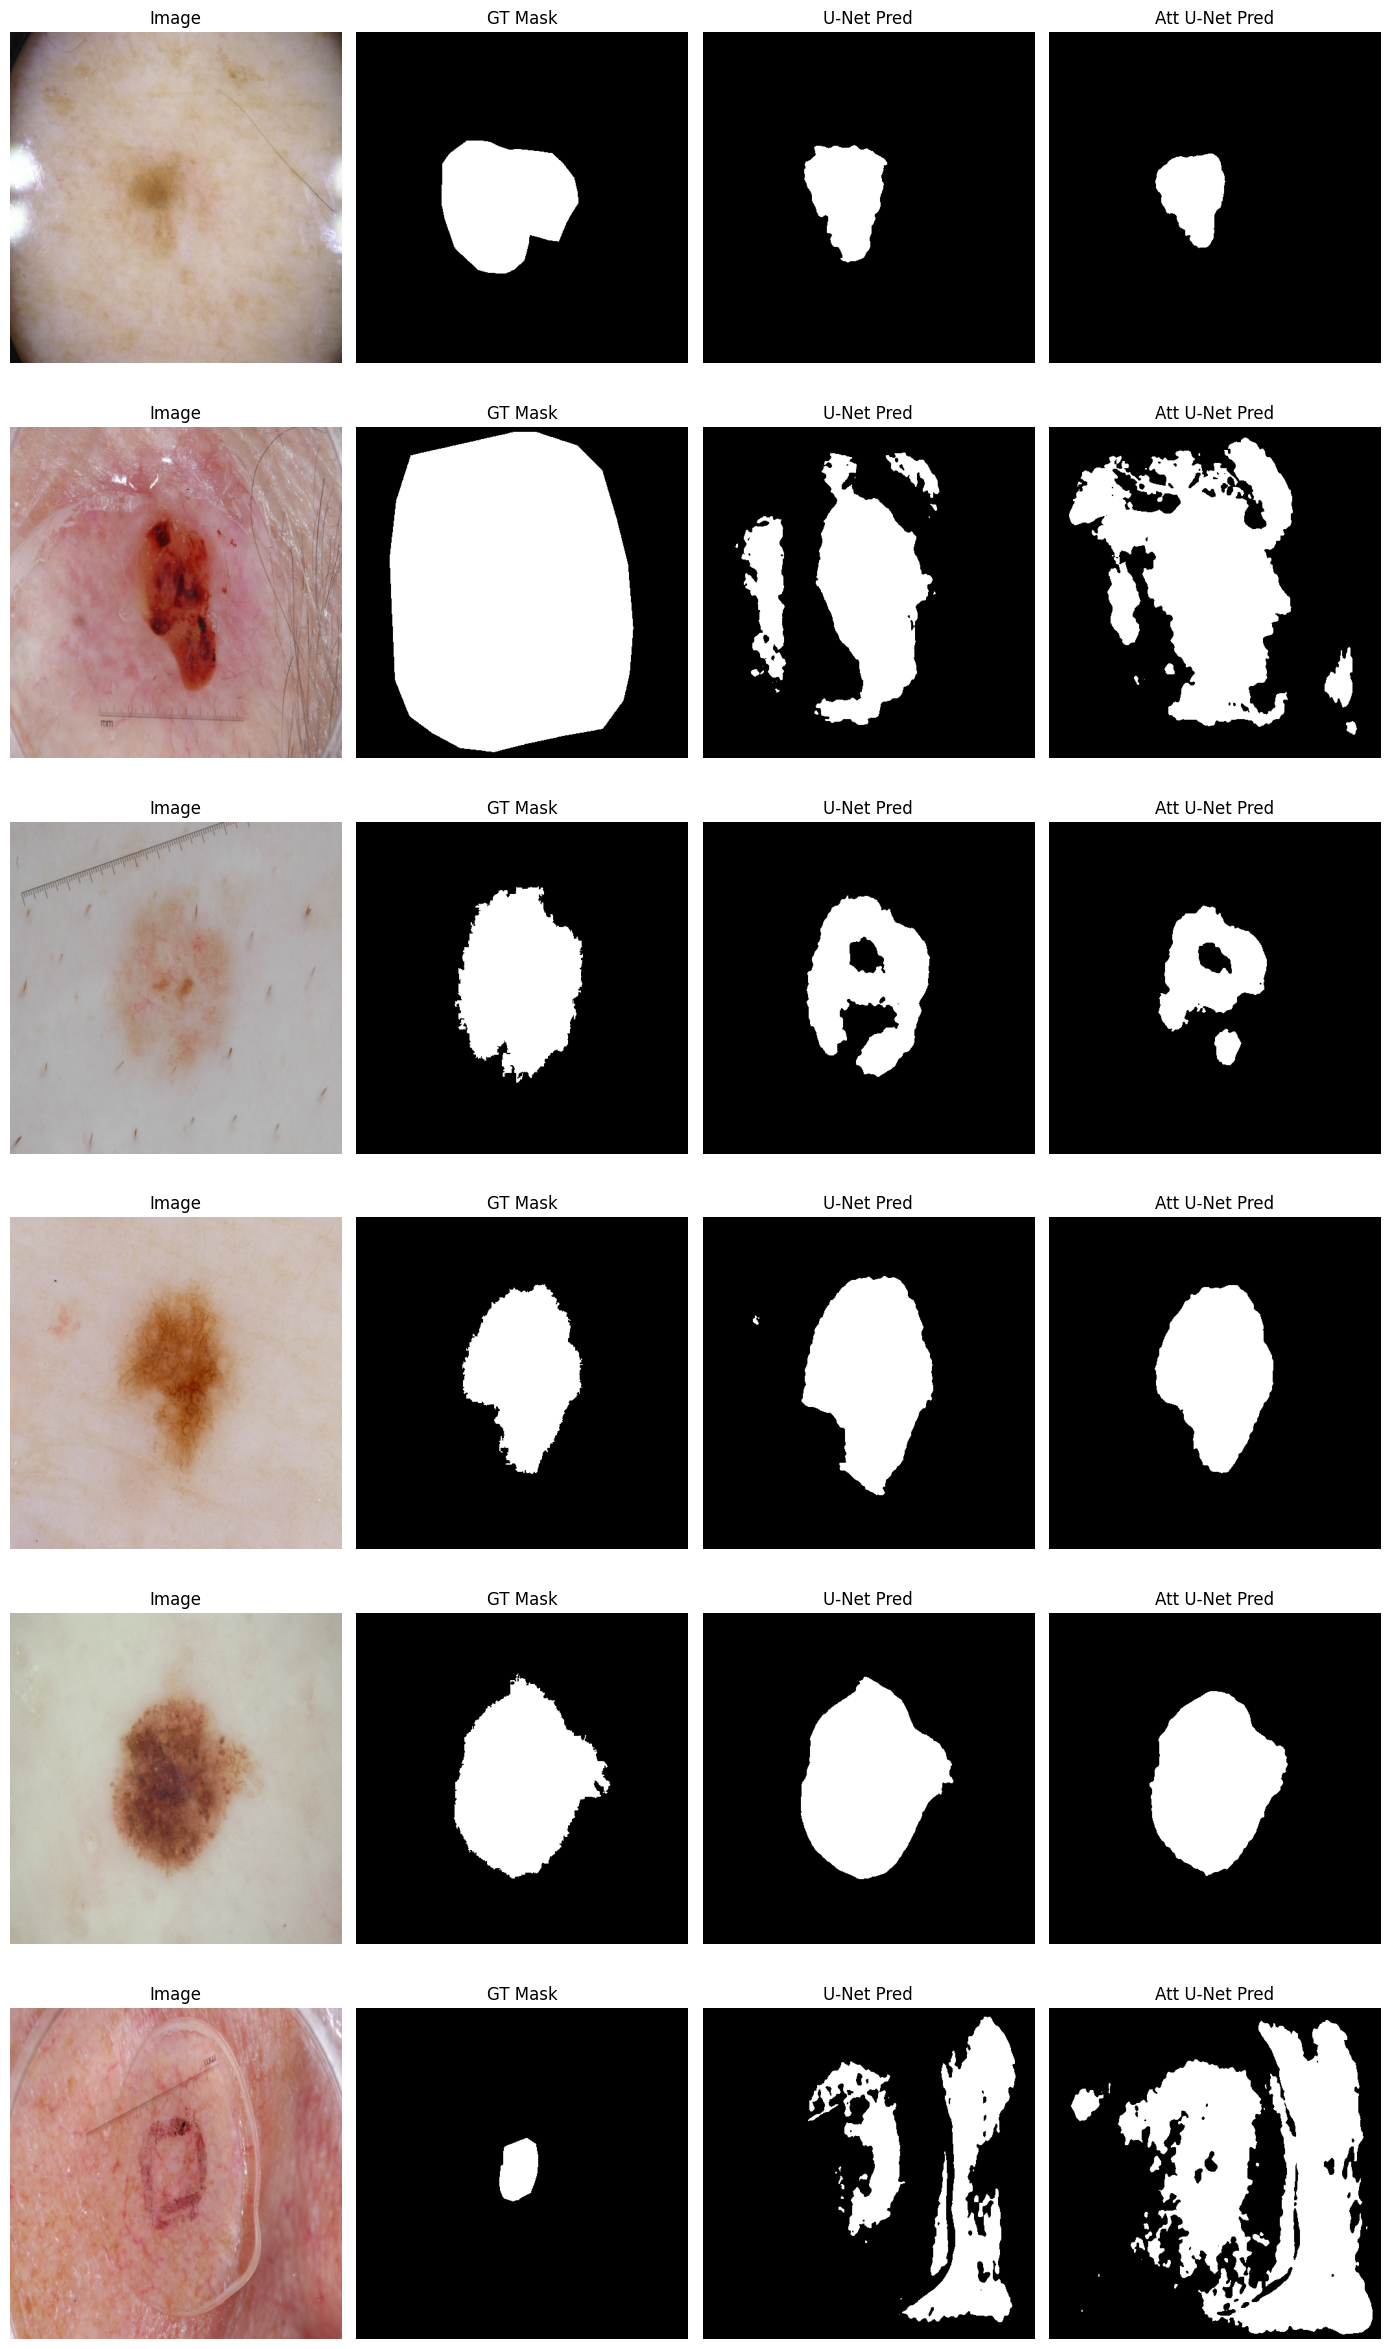

In [ ]:
@torch.no_grad()
def predict_mask(model, img_t):
    model.eval()
    img_t = img_t.unsqueeze(0).to(device)  # 1,3,H,W
    logits = model(img_t)
    prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
    pred = (prob >= CFG["THRESHOLD"]).astype(np.uint8)
    return prob, pred

def visualize_predictions(unet_model, att_model, dataset, n=6, seed=123):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(dataset)), k=min(n, len(dataset)))

    plt.figure(figsize=(14, 4*n))
    for i, idx in enumerate(idxs, 1):
        img_t, mask_t = dataset[idx]
        img = (img_t.permute(1,2,0).numpy() * 255).astype(np.uint8)
        gt  = mask_t[0].numpy().astype(np.uint8)

        _, unet_pred = predict_mask(unet_model, img_t)
        _, att_pred  = predict_mask(att_model, img_t)

        for j, (title, arr, cmap) in enumerate([
            ("Image", img, None),
            ("GT Mask", gt, "gray"),
            ("U-Net Pred", unet_pred, "gray"),
            ("Att U-Net Pred", att_pred, "gray"),
        ]):
            plt.subplot(n, 4, (i-1)*4 + (j+1))
            if arr.ndim == 3:
                plt.imshow(arr)
            else:
                plt.imshow(arr, cmap=cmap)
            plt.title(title)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(unet_model, att_model, test_ds, n=6, seed=123)


## Evaluasi

Gambar di atas menampilkan hasil segmentasi pada beberapa sampel test holdout.
Setiap baris merepresentasikan satu sampel, dengan urutan:
**Image → Ground Truth → U-Net Prediction → Attention U-Net Prediction**.

### Analisis per Kasus

**Sample A (baris pertama – lesi kecil, kontras rendah)**  
- Ground truth menunjukkan lesi kecil dengan batas tidak tegas.
- U-Net menghasilkan *under-segmentation*, namun masih mempertahankan bentuk utama lesi.
- Attention U-Net memprediksi area yang lebih kecil dan lebih terfokus, sehingga sebagian area lesi tidak terdeteksi.
- Kasus ini menunjukkan kecenderungan Attention U-Net terlalu agresif menekan area yang dianggap tidak relevan.

**Sample B (baris kedua – lesi besar, background kompleks)**  
- U-Net menghasilkan mask yang relatif menyatu, meskipun masih terdapat *false positive* di sekitar lesi.
- Attention U-Net menghasilkan fragmentasi yang lebih parah, dengan area terputus-putus dan lubang (*holes*).
- Hal ini mengindikasikan attention gate sensitif terhadap variasi tekstur dan artefak di sekitar lesi.

**Sample C (baris ketiga – lesi sedang, batas cukup jelas)**  
- Kedua model berhasil mendeteksi area utama lesi.
- Namun, baik U-Net maupun Attention U-Net menghasilkan lubang di bagian tengah mask (*false negative internal*).
- Attention U-Net menghasilkan area yang lebih kecil dan kurang lengkap dibanding U-Net.

**Sample D (baris keempat – lesi dengan bentuk tidak simetris)**  
- U-Net mengikuti kontur lesi dengan cukup baik, meskipun terdapat sedikit over-segmentation.
- Attention U-Net menghasilkan mask yang lebih halus tetapi kehilangan sebagian detail bentuk lesi.
- Ini menunjukkan trade-off antara fokus lokal dan kelengkapan area.

**Sample E (baris kelima – lesi besar, kontras tinggi)**  
- Kedua model menghasilkan segmentasi yang stabil dan mendekati ground truth.
- Perbedaan antara U-Net dan Attention U-Net relatif kecil pada kasus dengan kontras tinggi dan batas jelas.

**Sample F (baris terakhir – lesi sangat kecil dengan artefak kuat)**  
- Kedua model mengalami kegagalan signifikan.
- U-Net menghasilkan *false positive* luas di area background.
- Attention U-Net menunjukkan fragmentasi yang lebih ekstrem akibat artefak dan noise.
- Kasus ini merupakan *failure case* untuk kedua model.

### Ringkasan
Secara keseluruhan:
- **U-Net** cenderung menghasilkan mask yang lebih **utuh dan stabil**.
- **Attention U-Net** sering menghasilkan prediksi yang lebih sempit dan terfragmentasi, terutama pada citra dengan artefak atau background kompleks.
- Observasi visual ini konsisten dengan evaluasi kuantitatif, di mana U-Net memperoleh nilai **IoU dan Dice lebih tinggi** pada test holdout.


## **7. Kesimpulan dan Saran**

### **Kesimpulan**
Riset ini membandingkan performa U-Net dan Attention U-Net pada tugas segmentasi lesi kulit menggunakan dataset ISIC 2018 Task 1, dengan evaluasi dilakukan secara offline pada holdout test split dari training set.

Berdasarkan evaluasi kuantitatif U-Net mencapai nilai IoU = 0.6639 dan Dice = 0.7609. Attention U-Net mencapai nilai IoU = 0.6036 dan Dice = 0.7102. Selisih performa menunjukkan bahwa U-Net unggul dengan ΔIoU = +0.0603 dan ΔDice = +0.0507 dibanding Attention U-Net.

Hasil evaluasi kualitatif memperkuat temuan ini, di mana U-Net menghasilkan segmentasi yang lebih utuh dan stabil pada berbagai ukuran dan bentuk lesi Attention U-Net cenderung menghasilkan mask yang lebih sempit dan terfragmentasi, terutama pada citra dengan artefak atau background kompleks. Pada beberapa kasus, attention gate justru menekan area lesi yang seharusnya terdeteksi, sehingga menyebabkan under-segmentation.

Dengan demikian, pada konfigurasi eksperimen ini (input 256×256, augmentasi sederhana, loss BCE + Dice), penambahan mekanisme attention tidak memberikan peningkatan performa dibanding U-Net standar untuk segmentasi lesi kulit ISIC 2018.

---

### **Saran**
Beberapa pengembangan yang dapat dilakukan pada penelitian selanjutnya:
1. Menggunakan augmentasi data yang lebih kaya untuk meningkatkan generalisasi, terutama pada citra dengan artefak dan kontras rendah.
2. Mencoba loss function alternatif (misalnya Tversky atau Focal Tversky) untuk menangani ketidakseimbangan area lesi dan background.
3. Melakukan threshold tuning dan cross-validation agar evaluasi lebih robust.


## Referensi

[1]H. Naseri and A. A. Safaei, “Diagnosis and prognosis of melanoma from dermoscopy images using machine learning and deep learning: a systematic literature review,” BMC Cancer, vol. 25, no. 1, Jan. 2025, doi: https://doi.org/10.1186/s12885-024-13423-y.

[2]“ISIC Challenge,” Isic-archive.com, 2018. https://challenge.isic-archive.com/landing/2018/45/.

[3]N. Codella et al., “Skin Lesion Analysis Toward Melanoma Detection 2018: A Challenge Hosted by the International Skin Imaging Collaboration (ISIC),” arXiv:1902.03368 [cs], Mar. 2019, Available: https://arxiv.org/abs/1902.03368

[4]O. Ronneberger, P. Fischer, and T. Brox, “U-Net: Convolutional networks for biomedical image segmentation,” arXiv (Cornell University), May 2015, doi: https://doi.org/10.48550/arxiv.1505.04597.

[5]O. Oktay et al., “Attention U-Net: Learning Where to Look for the Pancreas,” arXiv.org, 2018. https://arxiv.org/abs/1804.03999

‌